# Analiza sieciowa scenariusza filmowego

## Wersja studencka: od promptu do działającego kodu

Ten notatnik jest szablonem do pracy w Google Colab na zajęciach z humanistyki cyfrowej. Nie zawiera gotowych rozwiązań. Zamiast tego prowadzi Cię przez serię małych promptów, które możesz przekazać modelowi AI, a następnie wkleić wygenerowany kod do pustej komórki.

Efektem końcowym będzie:
1. pobranie i oczyszczenie tekstu scenariusza,
2. wydzielenie scen i postaci,
3. zbudowanie tabeli współwystąpień,
4. narysowanie sieci relacji,
5. zapisanie plików do dalszej analizy.

Wersja z wcześniejszymi rozwiązaniami została zachowana w pliku `analiza_sieciowa_scenariusza_prowadzacy.ipynb`.


## Jak pracować z tym notatnikiem

1. Zmień adres scenariusza w komórce parametru.
2. Skopiuj prompt z bieżącego kroku do modelu AI.
3. Wklej otrzymany kod do pustej komórki pod promptem.
4. Uruchom kod i porównaj rezultat z sekcją **Po uruchomieniu powinieneś zobaczyć**.
5. Jeśli wynik nie zgadza się z opisem, popraw tylko bieżący krok.
6. Dopiero po uzyskaniu poprawnego wyniku przejdź dalej.

W każdym kroku skupiamy się na jednym małym zadaniu. Nie próbuj rozwiązywać kilku etapów naraz. Najważniejszy wynik każdego kroku powinien pozostać dostępny do następnego kroku, ale to model ma zdecydować, jak to zorganizować w kodzie.


## Parametr startowy

To jedyna komórka, którą zmieniasz ręcznie przed rozpoczęciem pracy. Wybierz adres strony scenariusza z IMSDb.


In [1]:
# Jedyny parametr, który zmieniasz w tym notatniku
adres_scenariusza = "https://imsdb.com/scripts/Pirates-of-the-Caribbean.html"


In [2]:
adres_scenariusza

'https://imsdb.com/scripts/Pirates-of-the-Caribbean.html'

---
## Etap 1: Od strony internetowej do czystego tekstu

Najpierw upewniamy się, że pracujemy na właściwej stronie i że potrafimy oddzielić tekst scenariusza od pozostałych elementów witryny.


### Krok 1A. Pobranie strony i kontrola surowej odpowiedzi

#### Cel i sens analityczny

Zanim zaczniemy analizować scenariusz, trzeba potwierdzić, że wskazany adres rzeczywiście prowadzi do strony z treścią, na której da się pracować dalej.


#### Prompt dla modelu

```text
Kontekst:
Chcesz sprawdzić, czy adres podany w komórce parametru rzeczywiście prowadzi do strony ze scenariuszem filmowym.

Wejście:
Adres scenariusza zapisany w pierwszej komórce parametru.

Zadanie:
Pobierz zawartość tej strony i przygotuj krótki podgląd surowej odpowiedzi. Zachowaj pobraną treść tak, aby można było wykorzystać ją w następnym kroku bez ponownego pobierania.

Pokaż wynik:
- komunikat, czy pobranie się udało,
- końcowy adres strony po ewentualnym przekierowaniu,
- pierwsze 8-10 niepustych linii pobranej treści.

Warunek poprawności:
W wyniku powinny być widoczne elementy strony internetowej, a treść nie może być pusta.

Jeśli wystąpi błąd:
Wyświetl krótką informację, czy problem dotyczy adresu, braku połączenia albo pustej odpowiedzi.

Nie rób jeszcze:
Nie wydobywaj tekstu scenariusza i nie analizuj jego struktury.
```


In [3]:
import requests

raw_html_content = ""
final_url = ""

try:
    response = requests.get(adres_scenariusza, allow_redirects=True, timeout=10)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

    raw_html_content = response.text
    final_url = response.url

    print("Pobieranie strony: SUKCES")
    print(f"Końcowy adres URL: {final_url}")

    non_empty_lines = [line.strip() for line in raw_html_content.splitlines() if line.strip()]
    print("Pierwsze 10 niepustych linii treści:")
    for i, line in enumerate(non_empty_lines[:10]):
        print(line)

except requests.exceptions.RequestException as e:
    print("Pobieranie strony: BŁĄD")
    if isinstance(e, requests.exceptions.ConnectionError):
        print("Problem z połączeniem lub adresem.")
    elif isinstance(e, requests.exceptions.Timeout):
        print("Przekroczono limit czasu połączenia.")
    elif isinstance(e, requests.exceptions.HTTPError):
        print(f"Błąd HTTP: {e.response.status_code} - {e.response.reason}")
    else:
        print(f"Nieznany błąd podczas pobierania: {e}")
except Exception as e:
    print(f"Wystąpił nieoczekiwany błąd: {e}")

if not raw_html_content:
    print("Ostrzeżenie: Pobrano pustą treść strony.")

Pobieranie strony: SUKCES
Końcowy adres URL: https://imsdb.com/scripts/Pirates-of-the-Caribbean.html
Pierwsze 10 niepustych linii treści:
<html>
<head>
<!-- Google tag (gtag.js) -->
<script async src="https://www.googletagmanager.com/gtag/js?id=G-W5BXG8HCH3"></script>
<script>
window.dataLayer = window.dataLayer || [];
function gtag(){dataLayer.push(arguments);}
gtag('js', new Date());
gtag('config', 'G-W5BXG8HCH3');
</script>


#### Po uruchomieniu powinieneś zobaczyć


- Krótki komunikat potwierdzający, że strona została pobrana albo czytelne wyjaśnienie problemu.
- Końcowy adres strony, jeśli po drodze nastąpiło przekierowanie.
- Fragment surowej treści, który wygląda jak pełna strona internetowa, a nie jak pusty wynik.


### Krok 1B. Wydobycie właściwego tekstu scenariusza

#### Cel i sens analityczny

Strona zawiera menu, linki i elementy pomocnicze. Do dalszej analizy potrzebny jest tylko właściwy tekst scenariusza.


#### Prompt dla modelu

```text
Kontekst:
Surowa strona zawiera dużo elementów, które nie należą do scenariusza.

Wejście:
Pobrana treść strony z poprzedniego kroku.

Zadanie:
Wydobądź tylko właściwy tekst scenariusza i odrzuć menu, nagłówki, stopki, linki i inne elementy witryny. Zachowaj oczyszczony tekst tak, aby był dostępny w następnym kroku.

Pokaż wynik:
- krótki komunikat, że tekst scenariusza został odnaleziony,
- pierwsze 15 niepustych linii oczyszczonego tekstu.

Warunek poprawności:
W podglądzie powinien być widoczny układ scenariusza lub dialogów, a nie nawigacja strony.

Jeśli wystąpi błąd:
Wyjaśnij, że nie udało się odnaleźć głównego bloku z tekstem scenariusza albo że wynik nadal zawiera zbyt dużo treści pobocznych.

Nie rób jeszcze:
Nie licz znaków i nie rozpoznawaj scen ani postaci.
```


In [4]:
from bs4 import BeautifulSoup

cleaned_script_text = ""

try:
    soup = BeautifulSoup(raw_html_content, 'html.parser')

    # On IMSDb, the script content is usually within a <pre> tag
    script_block = soup.find('pre')

    if script_block:
        cleaned_script_text = script_block.get_text()
        print("Sukces: Tekst scenariusza został odnaleziony.")

        # Prepare preview
        lines = [line.strip() for line in cleaned_script_text.splitlines() if line.strip()]
        print("Pierwsze 15 niepustych linii oczyszczonego tekstu:")
        for line in lines[:15]:
            print(line)
    else:
        print("BŁĄD: Nie udało się odnaleźć głównego bloku z tekstem scenariusza (brak tagu <pre>).")

except Exception as e:
    print(f"Wystąpił błąd podczas oczyszczania tekstu: {e}")

Sukces: Tekst scenariusza został odnaleziony.
Pierwsze 15 niepustych linii oczyszczonego tekstu:
FADE IN:
EXT. CARIBBEAN SEA - DAY
A gray, impenetrable wall of fog. From somewhere comes the
FAINT SOUND of a LITTLE GIRL'S VOICE, singing, slow tempo,
almost under her breath.
YOUNG ELIZABETH (O.S.)
Yo, ho, yo, ho, a pirate's life for me
Yo, ho, yo, ho, it's a pirate's life
for me...
Suddenly a massive SHIP emerges from the grey, the Winged
Victory maidenhead looming. It's a British dreadnought,
the H.M.S. Dauntless. Formidable, frightening, twenty-five
gun ports on a side, and rail guns to boot.
EXT. H.M.S. DAUNTLESS - FORECASTLE - DAY
ELIZABETH SWANN, strawberry blond hair, stands at the bow


#### Po uruchomieniu powinieneś zobaczyć


- Potwierdzenie, że udało się odseparować właściwy tekst scenariusza.
- Kilkanaście pierwszych linii przypominających zapis scenariusza filmowego.
- Brak widocznego menu, stopki i innych elementów witryny.


### Krok 1C. Podgląd tekstu i szybka kontrola jakości

#### Cel i sens analityczny

Zanim przejdziemy dalej, warto upewnić się, że tekst scenariusza jest wystarczająco długi i wygląda wiarygodnie.


#### Prompt dla modelu

```text
Kontekst:
Przed analizą scen i postaci trzeba sprawdzić, czy oczyszczony tekst wygląda kompletnie.

Wejście:
Oczyszczony tekst scenariusza z poprzedniego kroku.

Zadanie:
Pokaż krótki podgląd tekstu oraz podstawowe informacje o jego rozmiarze. Jeśli tekst wygląda podejrzanie krótko albo zawiera głównie elementy witryny, wypisz ostrzeżenie. Zachowaj tekst do dalszej analizy.

Pokaż wynik:
- liczbę znaków,
- liczbę linii,
- fragment początku tekstu o długości mniej więcej 1000-1500 znaków.

Warunek poprawności:
Podgląd powinien przypominać początek scenariusza, a nie przypadkowy fragment strony internetowej.

Jeśli wystąpi błąd:
Wyświetl informację, że tekst jest pusty, zbyt krótki albo nadal wymaga oczyszczenia.

Nie rób jeszcze:
Nie rozpoznawaj scen i postaci.
```


In [5]:
if 'cleaned_script_text' in locals() and cleaned_script_text:
    char_count = len(cleaned_script_text)
    lines_list = cleaned_script_text.splitlines()
    line_count = len(lines_list)

    print(f"Statystyki tekstu:")
    print(f"- Liczba znaków: {char_count}")
    print(f"- Liczba linii: {line_count}")
    print("-" * 30)

    if char_count < 5000:
        print("OSTRZEŻENIE: Tekst wydaje się podejrzanie krótki. Sprawdź, czy proces oczyszczania przebiegł poprawnie.")

    print("Podgląd początku scenariusza (pierwsze 1500 znaków):")
    print(cleaned_script_text[:1500])
    print("\n[...]\n")

    if "<html" in cleaned_script_text.lower() or "<div" in cleaned_script_text.lower():
        print("OSTRZEŻENIE: W tekście wykryto tagi HTML. Możliwe, że oczyszczanie wymaga poprawy.")
else:
    print("BŁĄD: Brak oczyszczonego tekstu. Uruchom poprzedni krok (1B).")

Statystyki tekstu:
- Liczba znaków: 196588
- Liczba linii: 6684
------------------------------
Podgląd początku scenariusza (pierwsze 1500 znaków):
FADE IN:

EXT. CARIBBEAN SEA - DAY

A gray, impenetrable wall of fog. From somewhere comes the
FAINT SOUND of a LITTLE GIRL'S VOICE, singing, slow tempo,
almost under her breath.

                     YOUNG ELIZABETH (O.S.)
           Yo, ho, yo, ho, a pirate's life for me
           Yo, ho, yo, ho, it's a pirate's life
           for me...

Suddenly a massive SHIP emerges from the grey, the Winged
Victory maidenhead looming. It's a British dreadnought,
the H.M.S. Dauntless. Formidable, frightening, twenty-five
gun ports on a side, and rail guns to boot.

EXT. H.M.S. DAUNTLESS - FORECASTLE - DAY

ELIZABETH SWANN, strawberry blond hair, stands at the bow
railing, gazing at the seas, still singing --

                     ELIZABETH
           ...drink up me hearties, yo, ho...

JOSHAMEE GIBBS, who was born old, skin a dark leather,
clutches h

#### Po uruchomieniu powinieneś zobaczyć


- Dwie podstawowe liczby opisujące wielkość materiału: znaki i linie.
- Dłuższy fragment początku scenariusza, który da się ocenić wzrokowo.
- W razie problemu: ostrzeżenie, że materiał nie nadaje się jeszcze do dalszych kroków.


---
## Etap 2: Rozpoznanie struktury scenariusza

W tym etapie przechodzimy od ciągłego tekstu do uporządkowanej struktury: najpierw sceny, potem postacie, a na końcu pełna lista scen z przypisanymi bohaterami.


### Krok 2A. Wykrycie granic scen

#### Cel i sens analityczny

Scena jest podstawową jednostką analizy sieciowej. Najpierw musimy odnaleźć miejsca, w których scenariusz przechodzi do nowej sceny.


#### Prompt dla modelu

```text
Kontekst:
W scenariuszach filmowych nowe sceny są zwykle otwierane krótkimi nagłówkami opisującymi miejsce i czas akcji, często zaczynającymi się od skrótów oznaczających wnętrze lub plener.

Wejście:
Oczyszczony tekst scenariusza.

Zadanie:
Wykryj granice scen i zbuduj uporządkowaną listę scen z numerami oraz nagłówkami. Zachowaj ten wynik do kolejnego kroku.

Pokaż wynik:
- łączną liczbę rozpoznanych scen,
- pierwszych 8 rekordów w formie `numer sceny | nagłówek sceny`.

Warunek poprawności:
Nagłówki powinny wyglądać jak opisy miejsca i czasu akcji, a nie jak dialog lub didaskalia. Jeśli scenariusz ma niestandardowy zapis, krótko opisz przyjętą zasadę rozpoznawania scen.

Jeśli wystąpi błąd:
Wyjaśnij, że nie udało się znaleźć wyraźnych granic scen albo że wykryte nagłówki są zbyt niejednoznaczne.

Nie rób jeszcze:
Nie przypisuj postaci do scen.
```


In [6]:
import re

# Lista na przetworzone sceny
sceny_lista = []

# Wyrażenie regularne szukające nagłówków scen (np. EXT., INT., EXT/INT)
# Szukamy linii zaczynających się od tych fraz (po ewentualnych spacjach)
pattern = r'^(?:[ ]{0,10})(INT\.|EXT\.|INT\/EXT|EXT\/INT)\s+.*$'

current_scene_content = []
scene_count = 0

lines = cleaned_script_text.splitlines()

for line in lines:
    if re.match(pattern, line.strip(), re.IGNORECASE):
        # Jeśli już mamy jakąś scenę w toku, zapisujemy ją (choć w tym kroku zbieramy głównie nagłówki)
        scene_count += 1
        sceny_lista.append({
            'numer': scene_count,
            'naglowek': line.strip(),
            'tresc': [] # Tu trafi tekst sceny w przyszłości
        })
    elif sceny_lista:
        # Dodajemy treść do ostatnio znalezionej sceny
        sceny_lista[-1]['tresc'].append(line)

if not sceny_lista:
    print("BŁĄD: Nie udało się wykryć granic scen. Sprawdź formatowanie nagłówków w tekście.")
else:
    print(f"Łączna liczba rozpoznanych scen: {len(sceny_lista)}")
    print("-" * 30)
    print("numer sceny | nagłówek sceny")
    for scena in sceny_lista[:8]:
        print(f"{scena['numer']} | {scena['naglowek']}")

# Zasada rozpoznawania: Wykorzystano regex wykrywający linie zaczynające się od oznaczeń miejsca (INT./EXT.)."

Łączna liczba rozpoznanych scen: 137
------------------------------
numer sceny | nagłówek sceny
1 | EXT. CARIBBEAN SEA - DAY
2 | EXT. H.M.S. DAUNTLESS - FORECASTLE - DAY
3 | INT. GOVERNOR'S MANSION - ELIZABETH'S BEDROOM
4 | INT. GOVERNOR'S MANSION - FOYER - DAY
5 | EXT. GOVERNOR'S MANSION - DAY
6 | EXT. PORT ROYAL - HARBOR - DAY
7 | EXT. PORT ROYAL - DOCKS - DAY
8 | EXT. FORT CHARLES - DAY


#### Po uruchomieniu powinieneś zobaczyć


- Liczbę scen rozpoznanych w całym tekście.
- Krótką listę pierwszych nagłówków, które wyglądają jak kolejne miejsca lub momenty akcji.
- Ewentualną krótką notatkę, jeśli scenariusz używa nietypowego formatu nagłówków.


### Krok 2B. Wykrycie kandydatów na nazwy postaci

#### Cel i sens analityczny

Sieć relacji budujemy z udziałem postaci, więc trzeba najpierw odróżnić ich nazwy od innych elementów zapisu scenariusza.


#### Prompt dla modelu

```text
Kontekst:
Nazwy postaci w scenariuszach często są zapisane wielkimi literami, wyraźnie odsunięte od lewego marginesu i czasem mają dopiski w nawiasach, które trzeba usunąć.

Wejście:
Oczyszczony tekst scenariusza.

Zadanie:
Znajdź kandydatów na nazwy postaci, oczyść je z dopisków w nawiasach i odfiltruj oczywiste instrukcje reżyserskie, przejścia montażowe oraz inne elementy, które nie są postaciami. Zachowaj wynik do kolejnego kroku.

Pokaż wynik:
- liczbę unikalnych kandydatów po oczyszczeniu,
- próbkę 20 rekordów w formie `oryginalny zapis | oczyszczona nazwa`.

Warunek poprawności:
Na liście powinny dominować imiona lub nazwy postaci, a nie komendy typu przejście, opis kamery albo tytuł karty.

Jeśli wystąpi błąd:
Pokaż kilka problematycznych przykładów i krótko wyjaśnij, dlaczego trudno je rozstrzygnąć.

Nie rób jeszcze:
Nie przypisuj postaci do konkretnych scen.
```


In [7]:
import re

TECHNICAL_EXCLUSIONS = {
    'FADE IN:', 'FADE OUT:', 'CUT TO:', 'DISSOLVE TO:', 'CONTINUED',
    'EXT.', 'INT.', 'SMASH CUT:', 'BACK TO SCENE', 'THE END',
    'CREDITS', 'LATER', 'YEARS', 'MINUTES', 'MOMENTS', 'ACT ', 'SCENE'
}

postacie_map = {}
char_pattern = r'^([ ]{10,30})([A-Z]{2,}.*)$'

surowe_nazwy_set = set()
for line in cleaned_script_text.splitlines():
    match = re.match(char_pattern, line)
    if match:
        raw_name = match.group(2).strip()
        clean_name = re.sub(r'\s*\(.*?\)', '', raw_name).strip()
        if any(term in clean_name for term in TECHNICAL_EXCLUSIONS): continue
        if clean_name and len(clean_name.split()) <= 4 and not clean_name.endswith('.'):
            if not any(x in clean_name for x in [':', '/', '!', '?']):
                if clean_name == 'MULLR0Y': clean_name = 'MULLROY'
                surowe_nazwy_set.add(clean_name)

posortowane_nazwy = sorted(list(surowe_nazwy_set), key=len, reverse=True)
finalna_konsolidacja = {}

for nazwa in posortowane_nazwy:
    znalazlem_dluzsza = False
    for dluzsza in finalna_konsolidacja.keys():
        if nazwa in dluzsza and nazwa != dluzsza:
            finalna_konsolidacja[nazwa] = dluzsza
            znalazlem_dluzsza = True
            break
    if not znalazlem_dluzsza:
        finalna_konsolidacja[nazwa] = nazwa

# Ręczne wymuszenie zmiany YOUNG ELIZABETH -> ELIZABETH
for k in list(finalna_konsolidacja.keys()):
    if 'YOUNG ELIZABETH' in finalna_konsolidacja[k]:
        finalna_konsolidacja[k] = 'ELIZABETH'
    if k == 'YOUNG ELIZABETH':
        finalna_konsolidacja[k] = 'ELIZABETH'

for line in cleaned_script_text.splitlines():
    match = re.match(char_pattern, line)
    if match:
        raw_name = match.group(2).strip()
        clean_name = re.sub(r'\s*\(.*?\)', '', raw_name).strip()
        if clean_name == 'MULLR0Y': clean_name = 'MULLROY'
        if clean_name in finalna_konsolidacja:
            postacie_map[raw_name] = finalna_konsolidacja[clean_name]

unikalne_postacie = sorted(list(set(postacie_map.values())))
print(f"Liczba unikalnych postaci: {len(unikalne_postacie)}")
print(f"Przykłady: YOUNG ELIZABETH -> {finalna_konsolidacja.get('YOUNG ELIZABETH')}")

Liczba unikalnych postaci: 33
Przykłady: YOUNG ELIZABETH -> ELIZABETH


#### Po uruchomieniu powinieneś zobaczyć


- Liczbę rozpoznanych nazw po oczyszczeniu.
- Próbkę zapisów pokazującą, jak surowe nazwy zostały uproszczone do postaci możliwych do porównywania.
- Brak dominacji elementów technicznych scenariusza nad rzeczywistymi postaciami.


### Krok 2C. Zbudowanie listy scen z postaciami

#### Cel i sens analityczny

Dopiero po połączeniu scen i postaci otrzymujemy strukturę, z której można obliczać współwystąpienia.


#### Prompt dla modelu

```text
Kontekst:
Masz już rozpoznane granice scen oraz kandydatów na nazwy postaci.

Wejście:
Wynik kroku z granicami scen i wynik kroku z rozpoznanymi postaciami.

Zadanie:
Zbuduj finalną listę scen. Każda scena ma zawierać numer, nagłówek oraz zbiór unikalnych postaci obecnych w tej scenie. Jeśli w danej scenie nie uda się rozpoznać żadnej postaci, zaznacz to jasno. Zachowaj listę scen do dalszych obliczeń.

Pokaż wynik:
- łączną liczbę scen,
- 5 przykładowych rekordów w formie `numer sceny | nagłówek | postacie`.

Warunek poprawności:
Ta sama postać nie powinna być powtórzona kilka razy w obrębie jednej sceny.

Jeśli wystąpi błąd:
Wyświetl krótką informację, czy problem dotyczy scen bez postaci, czy niespójności między wcześniejszymi krokami.

Nie rób jeszcze:
Nie buduj jeszcze rankingu postaci ani relacji między nimi.
```


In [8]:
finalna_lista_scen = []
mapa_oryginal_na_czyste = postacie_map
for scena in sceny_lista:
    postacie_w_scenie = set()
    for linia in scena['tresc']:
        trimmed_line = linia.strip()
        if trimmed_line in mapa_oryginal_na_czyste:
            imie = mapa_oryginal_na_czyste[trimmed_line]
            postacie_w_scenie.add(imie)
    finalna_lista_scen.append({
        'numer': scena['numer'],
        'naglowek': scena['naglowek'],
        'postacie': sorted(list(postacie_w_scenie))
    })
print("Zaktualizowano listę scen.")

Zaktualizowano listę scen.


#### Po uruchomieniu powinieneś zobaczyć


- Liczbę scen gotowych do dalszej analizy.
- Pięć czytelnych rekordów pokazujących numer sceny, jej nagłówek i listę rozpoznanych postaci.
- Jasną informację, jeśli część scen pozostała bez przypisanych postaci.


---
## Etap 3: Które postacie są najważniejsze?

Zanim zbudujemy sieć relacji, sprawdzamy rozkład obecności postaci w scenach. To prosty, ale bardzo użyteczny punkt wyjścia do interpretacji.


### Krok 3A. Ranking postaci według liczby scen

#### Cel i sens analityczny

Liczba scen, w których pojawia się dana postać, daje pierwszą miarę jej znaczenia w strukturze narracji.


#### Prompt dla modelu

```text
Kontekst:
Masz listę scen, z których każda zawiera unikalne postacie.

Wejście:
Finalna lista scen z przypisanymi postaciami.

Zadanie:
Policz, w ilu różnych scenach pojawia się każda postać. Posortuj wynik od najwyższego do najniższego. Zachowaj ranking do następnego kroku.

Pokaż wynik:
- łączną liczbę unikalnych postaci,
- tabelę 20 najwyższych wyników w formie `postać | liczba scen`.

Warunek poprawności:
W obrębie jednej sceny dana postać może zostać policzona tylko raz.

Jeśli wystąpi błąd:
Wyświetl informację, że lista scen jest pusta albo że nie udało się rozpoznać postaci w wystarczającej liczbie scen.

Nie rób jeszcze:
Nie rysuj wykresu i nie buduj relacji między postaciami.
```


In [9]:
from collections import Counter
ranking_counter = Counter()
for scena in finalna_lista_scen:
    for postac in scena['postacie']:
        ranking_counter[postac] += 1
ranking_postaci = ranking_counter.most_common()
print("Top 10 postaci:")
for p, count in ranking_postaci[:10]:
    print(f"{p} | {count}")

Top 10 postaci:
JACK | 49
WILL | 33
ELIZABETH | 27
BARBOSSA | 19
NORRINGTON | 16
PINTEL | 15
GIBBS | 10
SWANN | 9
GILLETTE | 7
ANAMARIA | 6


#### Po uruchomieniu powinieneś zobaczyć


- Krótką tabelę rankingową z najczęściej występującymi postaciami.
- Łączną liczbę rozpoznanych postaci.
- Wyniki posortowane malejąco według liczby scen.


#### Pytanie interpretacyjne

Które postacie dominują w strukturze scen i czy ten ranking zgadza się z Twoją intuicją o bohaterach filmu?


### Krok 3B. Wykres 10 najczęściej występujących postaci

#### Cel i sens analityczny

Wizualizacja pozwala szybko ocenić, czy scenariusz jest skupiony wokół jednej postaci, czy raczej rozkłada uwagę na kilka figur.


#### Prompt dla modelu

```text
Kontekst:
Masz już gotowy ranking liczby scen przypisanych do postaci.

Wejście:
Ranking postaci z poprzedniego kroku.

Zadanie:
Narysuj czytelny poziomy wykres dla 10 postaci o największej liczbie scen. Dodaj tytuł oraz opisy osi. Zachowaj ranking do dalszej pracy.

Pokaż wynik:
- pojedynczy wykres obejmujący tylko 10 najwyższych wyników,
- czytelne nazwy postaci,
- porządek od najwyższego do najniższego wyniku.

Warunek poprawności:
Jeśli ranking zawiera mniej niż 10 postaci, narysuj tyle, ile jest dostępnych, i wyraźnie to zaznacz.

Jeśli wystąpi błąd:
Wyświetl krótkie wyjaśnienie, dlaczego nie da się przygotować wykresu.

Nie rób jeszcze:
Nie buduj jeszcze relacji współwystąpień.
```


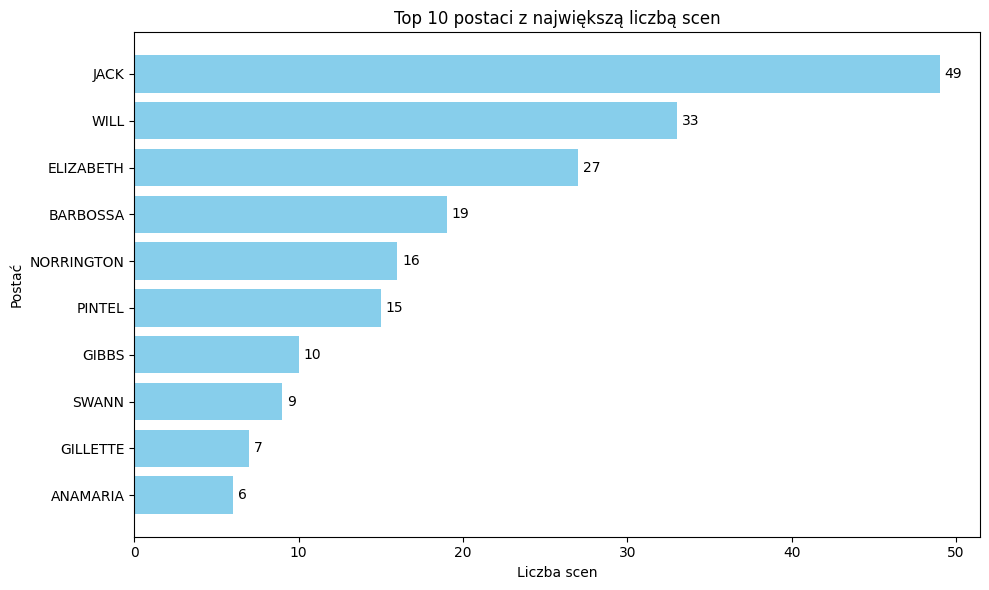

In [10]:
import matplotlib.pyplot as plt

if 'ranking_postaci' in locals() and ranking_postaci:
    # Pobieramy top 10 postaci (lub mniej, jeśli lista jest krótka)
    top_10 = ranking_postaci[:10]

    # Rozpakowujemy dane do osobnych list dla wykresu
    imiona = [p[0] for p in top_10]
    wartosci = [p[1] for p in top_10]

    # Odwracamy kolejność, aby najwyższy wynik był na górze wykresu poziomego
    imiona.reverse()
    wartosci.reverse()

    plt.figure(figsize=(10, 6))
    bars = plt.barh(imiona, wartosci, color='skyblue')

    plt.xlabel('Liczba scen')
    plt.ylabel('Postać')
    plt.title('Top 10 postaci z największą liczbą scen')

    # Dodanie etykiet z wartościami na końcach słupków
    for bar in bars:
        plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{int(bar.get_width())}', va='center')

    plt.tight_layout()
    plt.show()
else:
    print("BŁĄD: Ranking postaci nie jest dostępny. Uruchom poprzedni krok (3A).")

#### Po uruchomieniu powinieneś zobaczyć


- Jeden poziomy wykres z nazwami postaci i długościami słupków odpowiadającymi liczbie scen.
- Wyraźny tytuł i podpisane osie.
- Brak dodatkowych elementów, które utrudniałyby szybkie odczytanie rankingu.


#### Pytanie interpretacyjne

Czy rozkład obecności postaci wygląda na skoncentrowany wokół jednej osi fabularnej, czy bardziej rozproszony między kilka ważnych postaci?


---
## Etap 4: Od scen do relacji między postaciami

Tutaj przechodzimy od obecności postaci do ich współwystępowania. To właśnie z tych danych powstanie sieć relacji.


### Krok 4A. Pary współwystąpień wewnątrz pojedynczych scen

#### Cel i sens analityczny

Każda scena z co najmniej dwiema postaciami dostarcza zestawu potencjalnych relacji, które można później zagregować w całym scenariuszu.


#### Prompt dla modelu

```text
Kontekst:
Relacja między dwiema postaciami pojawia się wtedy, gdy obie występują w tej samej scenie.

Wejście:
Lista scen z unikalnymi postaciami.

Zadanie:
Dla każdej sceny wygeneruj wszystkie unikalne pary postaci występujących razem. Zachowaj wynik tak, aby można było później zsumować go dla całego scenariusza.

Pokaż wynik:
- liczbę scen, z których udało się utworzyć przynajmniej jedną parę,
- próbkę 15 wierszy w formie `numer sceny | postać A | postać B`.

Warunek poprawności:
Para nie może łączyć postaci z samą sobą, a ta sama para nie powinna pojawiać się podwójnie w obrębie jednej sceny. Zachowaj stały porządek zapisu par, aby później łatwo je sumować.

Jeśli wystąpi błąd:
Wyjaśnij, czy problem wynika z tego, że sceny mają zbyt mało postaci, czy z niespójności wcześniejszych danych.

Nie rób jeszcze:
Nie sumuj jeszcze wyników dla całego scenariusza.
```


In [11]:
from itertools import combinations

wszystkie_pary_scenami = []
sceny_z_relacjami_count = 0

for scena in finalna_lista_scen:
    postacie = scena['postacie']
    if len(postacie) >= 2:
        # Tworzymy wszystkie unikalne kombinacje 2-elementowe
        # combinations automatycznie dba o to, by nie było par (A, A)
        pary = list(combinations(sorted(postacie), 2))

        for pA, pB in pary:
            wszystkie_pary_scenami.append({
                'numer_sceny': scena['numer'],
                'postac_a': pA,
                'postac_b': pB
            })
        sceny_z_relacjami_count += 1

if not wszystkie_pary_scenami:
    print("BŁĄD: Nie udało się utworzyć żadnych par. Sceny zawierają zbyt mało postaci (wymagane min. 2).")
else:
    print(f"Liczba scen, w których występuje relacja (min. 2 postacie): {sceny_z_relacjami_count}")
    print(f"Łączna liczba wygenerowanych wystąpień par: {len(wszystkie_pary_scenami)}")
    print("-" * 50)
    print("numer sceny | postać A | postać B")
    for para in wszystkie_pary_scenami[:15]:
        print(f"{para['numer_sceny']} | {para['postac_a']} | {para['postac_b']}")

Liczba scen, w których występuje relacja (min. 2 postacie): 71
Łączna liczba wygenerowanych wystąpień par: 256
--------------------------------------------------
numer sceny | postać A | postać B
2 | ELIZABETH | GIBBS
2 | ELIZABETH | NORRINGTON
2 | ELIZABETH | SWANN
2 | ELIZABETH | WILL
2 | GIBBS | NORRINGTON
2 | GIBBS | SWANN
2 | GIBBS | WILL
2 | NORRINGTON | SWANN
2 | NORRINGTON | WILL
2 | SWANN | WILL
3 | BUTLER | ELIZABETH
3 | BUTLER | SWANN
3 | ELIZABETH | SWANN
4 | ELIZABETH | SWANN
4 | ELIZABETH | WILL


#### Po uruchomieniu powinieneś zobaczyć


- Informację, z ilu scen udało się utworzyć relacje.
- Próbkę pojedynczych par współwystąpień przypisanych do numerów scen.
- Brak duplikatów tej samej pary w obrębie jednej sceny.


### Krok 4B. Tabela relacji dla całego scenariusza

#### Cel i sens analityczny

Po zsumowaniu wszystkich par otrzymujemy podstawową tabelę krawędzi, z której można już budować sieć.


#### Prompt dla modelu

```text
Kontekst:
Masz listę par współwystąpień wygenerowanych dla poszczególnych scen.

Wejście:
Wynik kroku z parami współwystąpień.

Zadanie:
Zsumuj wszystkie powtarzające się pary w całym scenariuszu i utwórz tabelę relacji. Każda relacja ma opisywać, jak często dana para postaci występuje razem. Zachowaj tę tabelę do etapów sieciowych.

Pokaż wynik:
- liczbę unikalnych relacji,
- 15 najsilniejszych wierszy w formie `postać A | postać B | siła relacji`.

Warunek poprawności:
Ta sama relacja nie może pojawiać się kilka razy pod różnymi wariantami kolejności zapisu.

Jeśli wystąpi błąd:
Wyświetl krótką informację, że nie udało się utworzyć relacji albo że wynik jest pusty.

Nie rób jeszcze:
Nie buduj jeszcze sieci i nie zapisuj plików.
```


In [12]:
from itertools import combinations
from collections import Counter

wszystkie_pary_scenami = []
for scena in finalna_lista_scen:
    if len(scena['postacie']) >= 2:
        pary = list(combinations(sorted(scena['postacie']), 2))
        for pA, pB in pary:
            wszystkie_pary_scenami.append({'postac_a': pA, 'postac_b': pB})

relacje_counter = Counter()
for para in wszystkie_pary_scenami:
    relacje_counter[(para['postac_a'], para['postac_b'])] += 1

tabela_relacji = [{'postac_a': k[0], 'postac_b': k[1], 'sila': v} for k, v in relacje_counter.most_common()]
print(f"Liczba relacji: {len(tabela_relacji)}")
print("Najsilniejsze relacje:")
for r in tabela_relacji[:10]:
    print(f"{r['postac_a']} | {r['postac_b']} | {r['sila']}")

Liczba relacji: 104
Najsilniejsze relacje:
JACK | WILL | 23
ELIZABETH | JACK | 13
ELIZABETH | WILL | 8
BARBOSSA | PINTEL | 8
GIBBS | WILL | 7
JACK | NORRINGTON | 7
NORRINGTON | SWANN | 6
ELIZABETH | PINTEL | 6
BARBOSSA | ELIZABETH | 6
GIBBS | JACK | 6


#### Po uruchomieniu powinieneś zobaczyć


- Liczbę unikalnych relacji między postaciami.
- Tabelę pokazującą najsilniejsze duety wraz z siłą ich współwystępowania.
- Wyniki posortowane od najsilniejszej do najsłabszej relacji.


#### Pytanie interpretacyjne

Które duety wydają się centralne dla narracji i czy ich siła wynika raczej z długotrwałej osi fabuły, czy z wielu powracających spotkań?


---
## Etap 5: Sieć, podgląd i eksport danych

Na końcu zamieniamy tabelę relacji w sieć, oglądamy jej prosty podgląd i zapisujemy pliki do dalszej analizy poza Colabem.


### Krok 5A. Zbudowanie sieci relacji

#### Cel i sens analityczny

To moment przejścia od tabeli relacji do właściwej reprezentacji sieciowej, na której można liczyć miary i rysować strukturę powiązań.


#### Prompt dla modelu

```text
Kontekst:
Tabela relacji opisuje już, które postacie są połączone i jak silne jest to połączenie.

Wejście:
Tabela relacji z poprzedniego kroku.

Zadanie:
Zbuduj sieć, w której węzłami są postacie, a połączenia opisują ich współwystępowanie. Siła relacji ma zostać zachowana przy każdym połączeniu. Zachowaj gotową sieć do następnego kroku.

Pokaż wynik:
- liczbę węzłów,
- liczbę połączeń,
- krótką listę 10 postaci z największą liczbą połączeń.

Warunek poprawności:
Każda relacja z tabeli powinna pojawić się w sieci dokładnie raz.

Jeśli wystąpi błąd:
Wyjaśnij, że tabela relacji jest pusta albo niespójna i dlatego nie da się zbudować sieci.

Nie rób jeszcze:
Nie rysuj jeszcze grafu i nie zapisuj plików.
```


In [13]:
import networkx as nx

# Inicjalizacja grafu nieskierowanego
G = nx.Graph()

if 'tabela_relacji' in locals() and tabela_relacji:
    # Dodawanie krawędzi wraz z ich siłą (weight)
    for relacja in tabela_relacji:
        G.add_edge(relacja['postac_a'], relacja['postac_b'], weight=relacja['sila'])

    # Statystyki sieci
    liczba_wezlow = G.number_of_nodes()
    liczba_krawedzi = G.number_of_edges()

    print(f"Sieć została zbudowana poprawnie.")
    print(f"- Liczba węzłów (postaci): {liczba_wezlow}")
    print(f"- Liczba połączeń (relacji): {liczba_krawedzi}")
    print("-" * 30)

    # Ranking postaci według stopnia (liczby unikalnych sąsiadów)
    stopnie = dict(G.degree())
    ranking_polaczen = sorted(stopnie.items(), key=lambda x: x[1], reverse=True)

    print("Top 10 postaci z największą liczbą połączeń (degree):")
    for postac, stopien in ranking_polaczen[:10]:
        print(f"{postac} | {stopien} relacji")
else:
    print("BŁĄD: Tabela relacji jest pusta lub niedostępna. Uruchom krok 4B.")

Sieć została zbudowana poprawnie.
- Liczba węzłów (postaci): 33
- Liczba połączeń (relacji): 104
------------------------------
Top 10 postaci z największą liczbą połączeń (degree):
JACK | 22 relacji
ELIZABETH | 21 relacji
WILL | 14 relacji
NORRINGTON | 13 relacji
PINTEL | 11 relacji
TWIGG | 11 relacji
BARBOSSA | 10 relacji
GIBBS | 10 relacji
SWANN | 9 relacji
KOEHLER | 9 relacji


#### Po uruchomieniu powinieneś zobaczyć


- Dwie podstawowe liczby opisujące wielkość sieci: węzły i połączenia.
- Krótką listę najlepiej połączonych postaci.
- Brak wizualizacji na tym etapie: chodzi tylko o potwierdzenie, że sieć została zbudowana poprawnie.


### Krok 5B. Podgląd grafu w notatniku

#### Cel i sens analityczny

Wizualny podgląd pomaga zobaczyć, czy sieć ma jedno centrum, kilka grup albo bardziej rozproszoną strukturę.


#### Prompt dla modelu

```text
Kontekst:
Masz już zbudowaną sieć relacji między postaciami.

Wejście:
Gotowa sieć z poprzedniego kroku.

Zadanie:
Narysuj prosty podgląd sieci bezpośrednio w notatniku. Niech bardziej połączone postacie będą lepiej widoczne, a silniejsze relacje wyraźniejsze. Dodaj etykiety przynajmniej dla najważniejszych postaci.

Pokaż wynik:
- pojedynczy rysunek sieci z tytułem,
- czytelne etykiety najważniejszych postaci,
- różnicę widoczną między słabszymi i silniejszymi relacjami.

Warunek poprawności:
Jeśli sieć jest bardzo gęsta, ogranicz liczbę etykiet albo uprość podgląd i krótko wyjaśnij ten wybór, zamiast tworzyć nieczytelny obraz.

Jeśli wystąpi błąd:
Wyświetl informację, że sieć jest zbyt mała albo zbyt gęsta, aby dało się ją pokazać w czytelnej formie bez dodatkowego uproszczenia.

Nie rób jeszcze:
Nie zapisuj jeszcze plików wyjściowych.
```


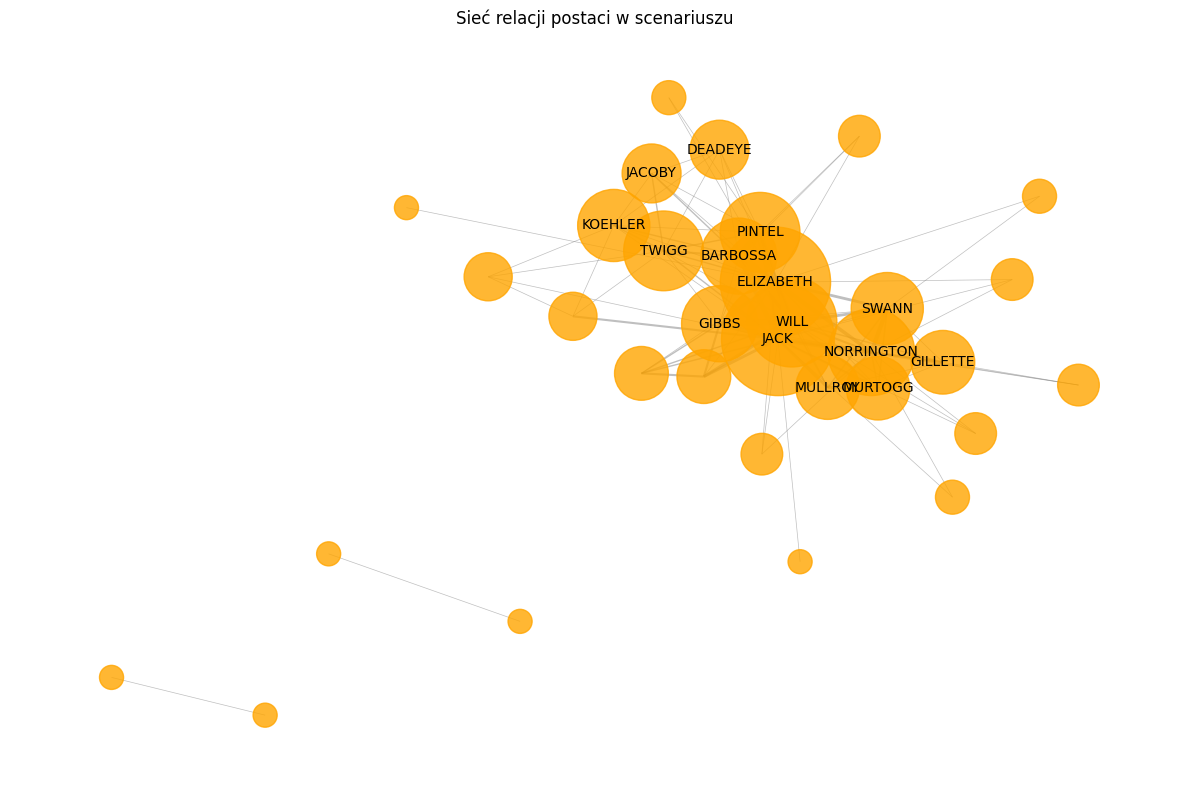

In [14]:
import matplotlib.pyplot as plt

if 'G' in locals() and G.number_of_nodes() > 0:
    plt.figure(figsize=(12, 8))

    # Układ grafu (spring layout dla naturalnego rozłożenia)
    pos = nx.spring_layout(G, k=0.5, seed=42)

    # Rozmiary węzłów zależne od stopnia (degree)
    node_sizes = [v * 300 for v in dict(G.degree()).values()]

    # Grubość krawędzi zależna od wagi (weight)
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    edge_widths = [w * 0.5 for w in weights]

    # Rysowanie
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='orange', alpha=0.8)
    nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color='gray', alpha=0.5)

    # Etykiety tylko dla najważniejszych postaci (top 15 według degree)
    top_nodes = sorted(dict(G.degree()).items(), key=lambda x: x[1], reverse=True)[:15]
    labels = {node: node for node, degree in top_nodes}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_family='sans-serif')

    plt.title("Sieć relacji postaci w scenariuszu")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("BŁĄD: Sieć nie została zbudowana. Uruchom krok 5A.")

#### Po uruchomieniu powinieneś zobaczyć


- Jeden rysunek sieci umieszczony bezpośrednio pod komórką.
- Większą widoczność postaci silniej osadzonych w sieci oraz wyraźniejsze relacje o większej sile.
- Krótką notę wyjaśniającą uproszczenie, jeśli sieć okaże się bardzo gęsta.


#### Pytanie interpretacyjne

Czy na podglądzie widać jednego głównego pośrednika, kilka grup postaci czy raczej gęstą strukturę bez wyraźnego centrum?


### Krok 5C. Eksport danych do dalszej analizy

#### Cel i sens analityczny

Ostatni krok przygotowuje dwa pliki, które można pobrać z Colab i analizować dalej w innych narzędziach.


#### Prompt dla modelu

```text
Kontekst:
Masz gotową tabelę relacji oraz zbudowaną sieć postaci.

Wejście:
Tabela relacji i gotowa sieć.

Zadanie:
Zapisz tabelę relacji do pliku `krawedzie.csv`, a całą sieć do pliku `graf_postaci.graphml`. Na końcu pokaż krótko, jakie pliki powstały i gdzie student może je znaleźć w środowisku notatnika.

Pokaż wynik:
- komunikat o zapisaniu obu plików,
- listę nazw zapisanych plików,
- krótką wskazówkę, jak pobrać je z Colab.

Warunek poprawności:
Oba pliki powinny być niepuste i gotowe do otwarcia poza notatnikiem.

Jeśli wystąpi błąd:
Wyjaśnij, którego pliku nie udało się zapisać i z jakiego powodu.

Nie rób jeszcze:
Nie wykonuj już dalszej analizy.
```


In [15]:
import pandas as pd
import networkx as nx
import os

try:
    # 1. Zapisywanie tabeli relacji do CSV
    df_relacje = pd.DataFrame(tabela_relacji)
    df_relacje.to_csv('krawedzie.csv', index=False)

    # 2. Zapisywanie grafu do GraphML
    nx.write_graphml(G, 'graf_postaci.graphml')

    print("SUKCES: Pliki zostały zapisane pomyślnie.")
    print(f"- krawedzie.csv ({os.path.getsize('krawedzie.csv')} bajtów)")
    print(f"- graf_postaci.graphml ({os.path.getsize('graf_postaci.graphml')} bajtów)")
    print("\nWskazówka: Kliknij ikonę folderu w lewym panelu bocznym Colab, aby znaleźć i pobrać pliki na swój komputer.")

except Exception as e:
    print(f"BŁĄD podczas zapisywania plików: {e}")

SUKCES: Pliki zostały zapisane pomyślnie.
- krawedzie.csv (1902 bajtów)
- graf_postaci.graphml (8903 bajtów)

Wskazówka: Kliknij ikonę folderu w lewym panelu bocznym Colab, aby znaleźć i pobrać pliki na swój komputer.


#### Po uruchomieniu powinieneś zobaczyć


- Potwierdzenie zapisania plików `krawedzie.csv` i `graf_postaci.graphml`.
- Krótką listę lub komunikat pokazujący, że pliki są widoczne w środowisku notatnika.
- Jednozdaniową wskazówkę, jak pobrać pliki z Google Colab.


---
## Co dalej?

- Otwórz `graf_postaci.graphml` w Gephi albo innym narzędziu do analizy sieci, aby policzyć miary centralności i sprawdzić społeczności postaci.
- Otwórz `krawedzie.csv` w arkuszu kalkulacyjnym, jeśli chcesz filtrować, sortować i porównywać relacje bez pracy na grafie.
- Zmień adres scenariusza w komórce parametru i porównaj strukturę narracyjną różnych filmów.
- Jeśli któryś krok działa źle, poproś model o poprawienie tylko tego jednego fragmentu zamiast generowania całego rozwiązania od nowa.
